<h1 style="text-align:center; color:red;">Mini-Project : Data Analysis for Marketing Strategy</h1>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [8]:
df = pd.read_excel("US Superstore data.xls")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [10]:
# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check missing values
df.isnull().sum()

# Basic information
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


### Which States Have the Most Sales?

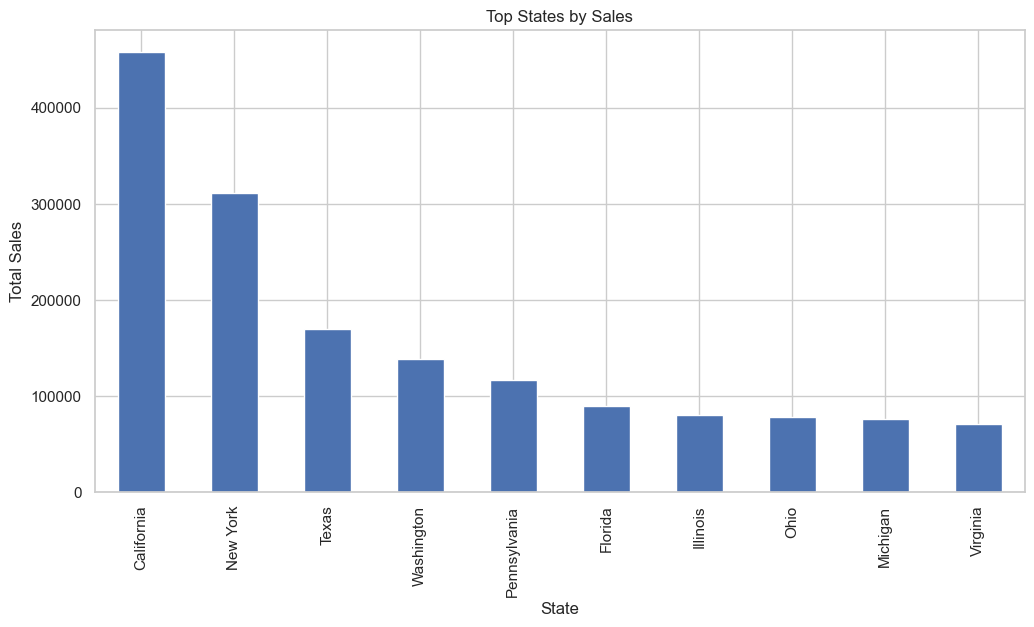

In [13]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_sales.head(10).plot(kind="bar")
plt.title("Top States by Sales")
plt.ylabel("Total Sales")
plt.show()

California, New York, and Texas are states that dominate sales.

### Compare New York and California

In [18]:
ny_ca = df[df["State"].isin(["New York","California"])]

comparison = ny_ca.groupby("State")[["Sales","Profit"]].sum()

comparison

,Sales,Profit
State,,
California,457687.6315,76381.3871
New York,310876.2710,74038.5486


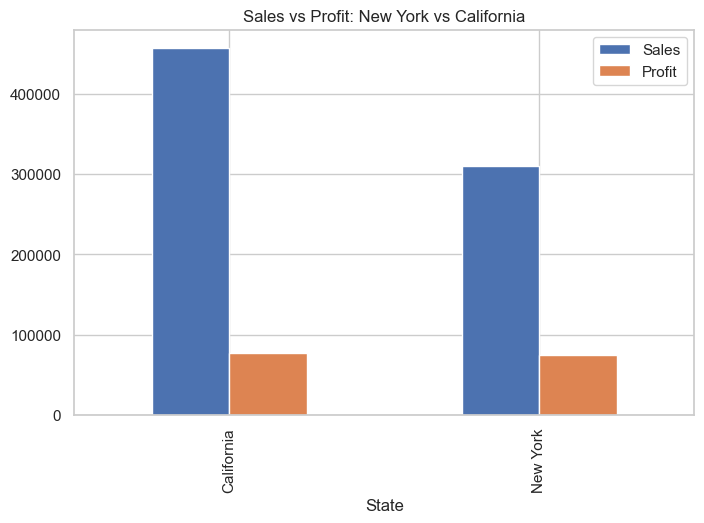

In [20]:
comparison.plot(kind="bar", figsize=(8,5))
plt.title("Sales vs Profit: New York vs California")
plt.show()

- California génère donc beaucoup plus de chiffre d'affaires.
- Les profits sont presque identiques malgré une grande différence de ventes.
- New York est plus rentable que California.

### Conclusion  

California:

- Marché très grand
- Génère le plus de ventes
- Idéal pour campagnes marketing de volume

New York:

- Marché plus rentable
- Génère presque autant de profit avec moins de ventes
- Idéal pour stratégies premium et fidélisation

### Recommandation 

- Continuer à investir marketing en California pour maximiser les ventes.
- Optimiser les marges en California (réduire les remises).
- Renforcer la stratégie client en New York car la rentabilité est meilleure.

## Outstanding Customer in New York

In [26]:
ny_customers = df[df["State"]=="New York"]

top_customer = ny_customers.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

top_customer.head(10)

Customer Name
Tom Ashbrook        13723.498
Peter Fuller         7678.228
Seth Vernon          7359.918
Tom Boeckenhauer     6999.960
Greg Tran            6712.744
Todd Sumrall         6492.314
Karen Daniels        6241.282
Keith Dawkins        5854.194
Luke Weiss           5048.186
Caroline Jumper      5012.760
Name: Sales, dtype: float64

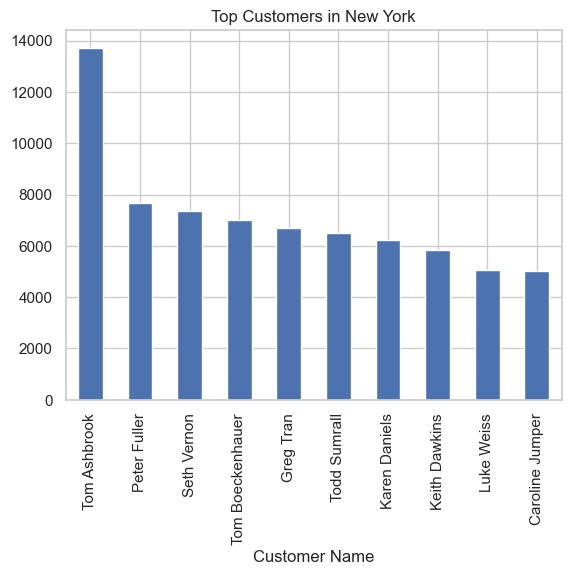

In [28]:
top_customer.head(10).plot(kind="bar")
plt.title("Top Customers in New York")
plt.show()

## Differences Among States in Profitability

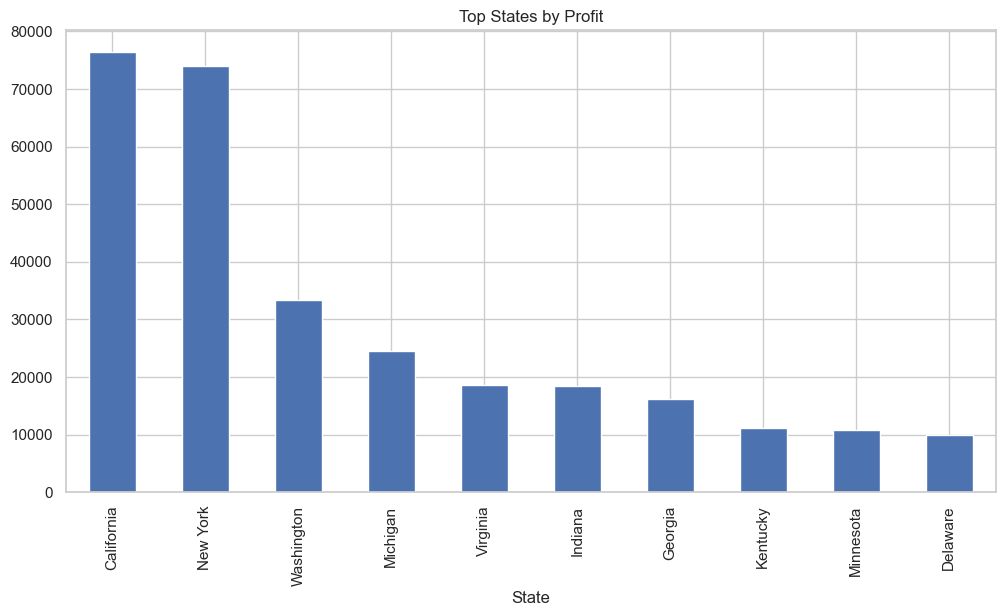

In [31]:
state_profit = df.groupby("State")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
state_profit.head(10).plot(kind="bar")
plt.title("Top States by Profit")
plt.show()

## Pareto Principle on Customers and Profit

In [47]:
customer_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False)

In [49]:
cum_profit = customer_profit.cumsum() / customer_profit.sum()

In [51]:
n_customers = len(customer_profit)
pareto_cutoff = int(0.2 * n_customers)

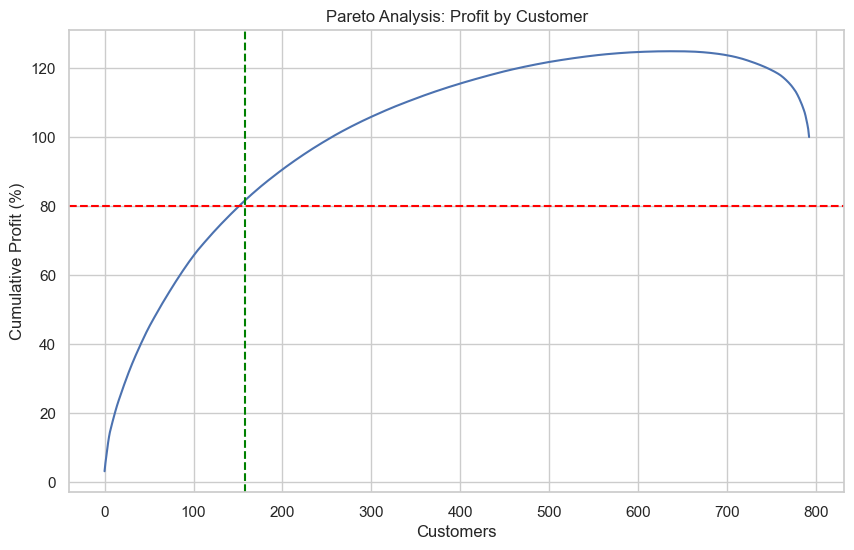

In [57]:
cum_profit_percentage = cum_profit * 100

plt.figure(figsize=(10,6))

plt.plot(cum_profit_percentage.values)
plt.axhline(y=80, color="red", linestyle="--")
plt.axvline(x=pareto_cutoff, color="green", linestyle="--")

plt.title("Pareto Analysis: Profit by Customer")
plt.xlabel("Customers")
plt.ylabel("Cumulative Profit (%)")

plt.show()

Oui, le principe de Pareto s’applique aux clients et au profit.

Environ 20 % des clients génèrent 80 % du profit total.

### Conclusion
#### Implications pour la stratégie marketing

#### Prioriser les clients à forte valeur

Les 150–160 clients les plus rentables doivent être ciblés avec :

- programmes de fidélité
- offres personnalisées
- service client premium

#### Optimiser les clients moins rentables

Pour les 80 % restants des clients, on peut :

- réduire les remises
- améliorer les marges
- automatiser certaines interactions

#### Focus marketing

Au lieu de cibler tous les clients, concentrer les efforts sur les clients les plus profitables permet :

- augmenter le ROI marketing
- améliorer la rentabilité

## Top 20 Cities by Sales

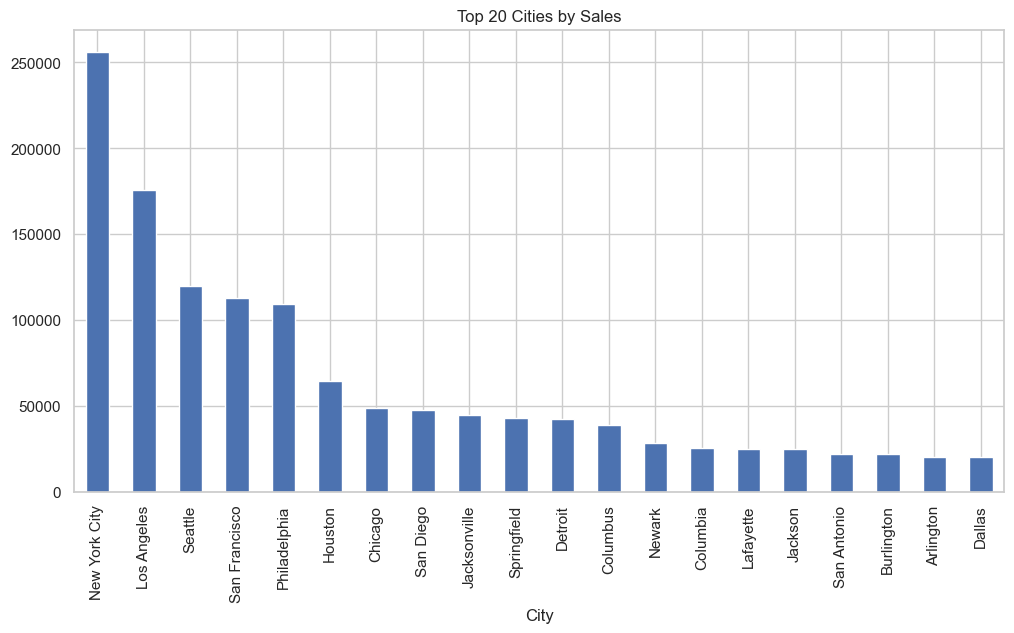

In [60]:
city_sales = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
city_sales.plot(kind="bar")
plt.title("Top 20 Cities by Sales")
plt.show()

## Top 20 Cities by Profit

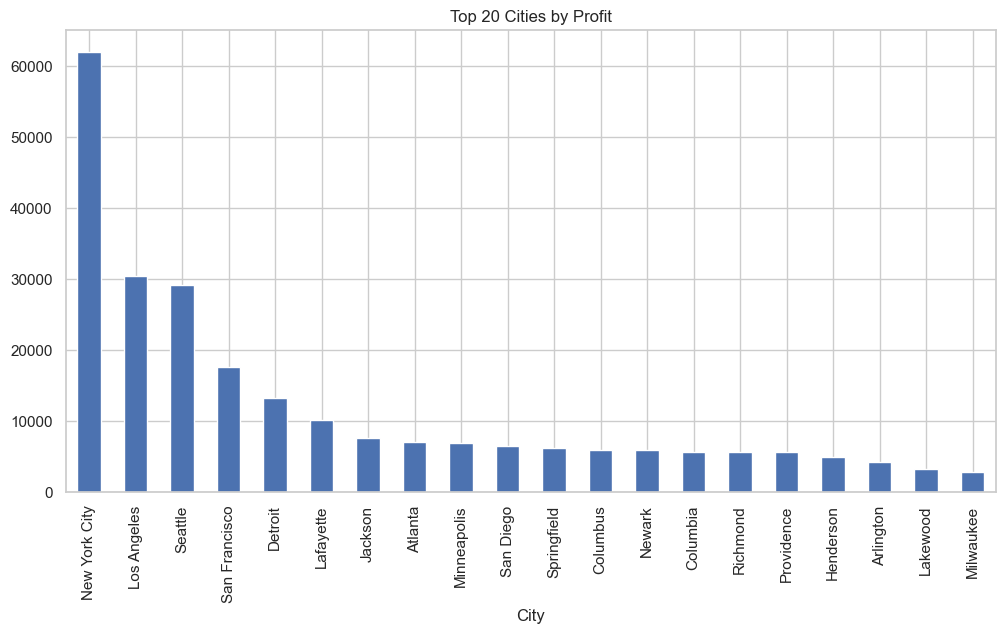

In [63]:
city_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
city_profit.plot(kind="bar")
plt.title("Top 20 Cities by Profit")
plt.show()

## Top 20 Customers by Sales

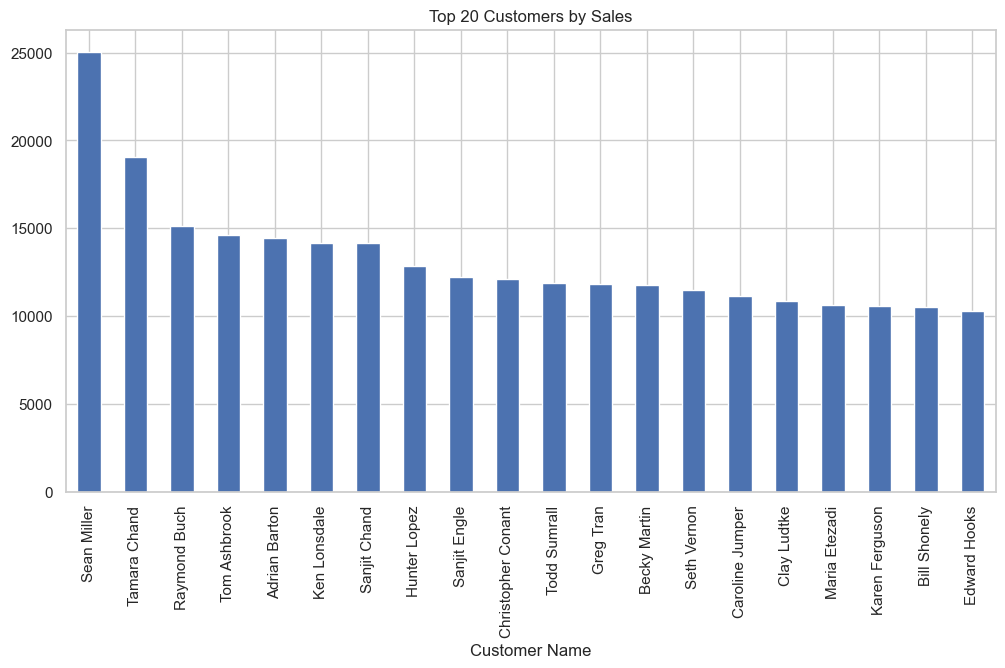

In [66]:
top_customers = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")
plt.title("Top 20 Customers by Sales")
plt.show()

### Cumulative Sales Curve (Pareto)

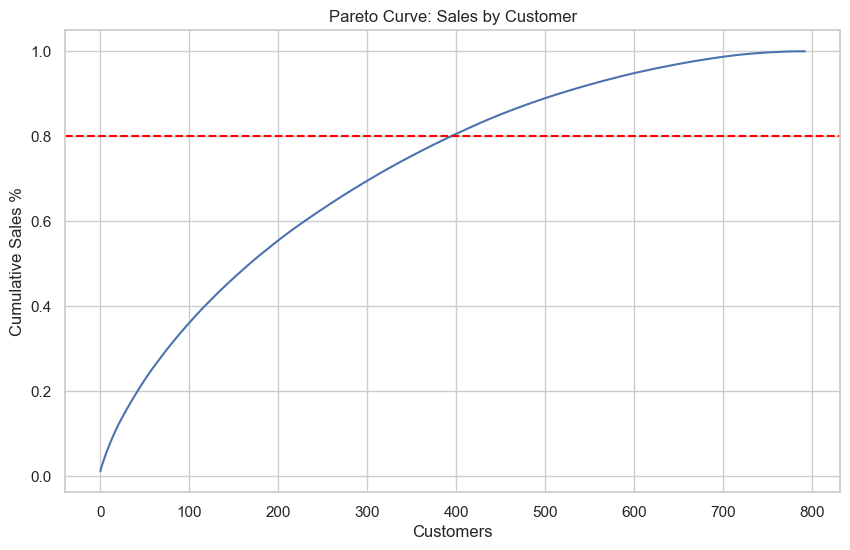

In [69]:
customer_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)

cum_sales = customer_sales.cumsum() / customer_sales.sum()

plt.figure(figsize=(10,6))
plt.plot(cum_sales.values)
plt.axhline(y=0.8, color="red", linestyle="--")
plt.title("Pareto Curve: Sales by Customer")
plt.xlabel("Customers")
plt.ylabel("Cumulative Sales %")
plt.show()

The cumulative sales curve shows that around 50% of customers generate 80% of total sales.

This means that the Pareto Principle (80/20 rule) does not strictly apply to customer sales in this dataset.

Instead of a small group of customers driving most of the revenue, a larger proportion of customers contributes significantly to total sales.

This indicates that sales are more evenly distributed among customers than expected under the Pareto principle.

Therefore:
- The business does not rely on a small group of customers for most of its sales.
- A broader customer base contributes to revenue generation.